# Part 3: NLP and Sequence Modeling - Customer Support Sentiment Classification

**Dataset:** `customer_support_text_classification.csv`  
**Target:** `sentiment_label` -> `negative` / `neutral` / `positive` (3-class)  
**Goal:** Compare classical text vectorization with a sequence-based BiLSTM model.


---
## Task 1: Dataset Understanding


In [26]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

os.makedirs('results', exist_ok=True)

df = pd.read_csv('customer_support_text_classification.csv')

print("=" * 55)
print("  DATASET OVERVIEW")
print("=" * 55)
print(f"  Rows       : {df.shape[0]}")
print(f"  Columns    : {df.shape[1]}")
print(f"  Unique msgs: {df['customer_message'].nunique()}")
print()
print("Columns:")
print(df.dtypes.to_string())


  DATASET OVERVIEW
  Rows       : 1500
  Columns    : 6
  Unique msgs: 634

Columns:
ticket_id           object
channel             object
customer_message    object
sentiment_label     object
word_count           int64
urgent_flag          int64


In [27]:
df.head(6)


,ticket_id,channel,customer_message,sentiment_label,word_count,urgent_flag
0,TKT00001,chat,I need information about the payment process. ...,neutral,18,1
1,TKT00002,phone,I need information about the payment process.,neutral,7,0
2,TKT00003,email,The refund process was fast and convenient. I ...,positive,12,0
3,TKT00004,social,My refund is still pending and this experience...,negative,15,1
4,TKT00005,chat,Please tell me how to update my account details.,neutral,9,0
5,TKT00006,social,I need help finding the invoice for my last or...,neutral,16,1


In [28]:
# Missing values
print("Missing values:"); print(df.isnull().sum().to_string())

# Average text length
df['char_count'] = df['customer_message'].str.len()
print(f"\nAvg word count   : {df['word_count'].mean():.2f}")
print(f"Avg char count   : {df['char_count'].mean():.1f}")
print(f"Max word count   : {df['word_count'].max()}")
print(f"Min word count   : {df['word_count'].min()}")


Missing values:
ticket_id           0
channel             0
customer_message    0
sentiment_label     0
word_count          0
urgent_flag         0

Avg word count   : 12.72
Avg char count   : 72.8
Max word count   : 26
Min word count   : 7


Sentiment distribution:
sentiment_label
neutral     524
negative    497
positive    479

Duplicate messages : 866 (57.7% of rows)
Synthetic dataset note: the same template messages repeat across rows.


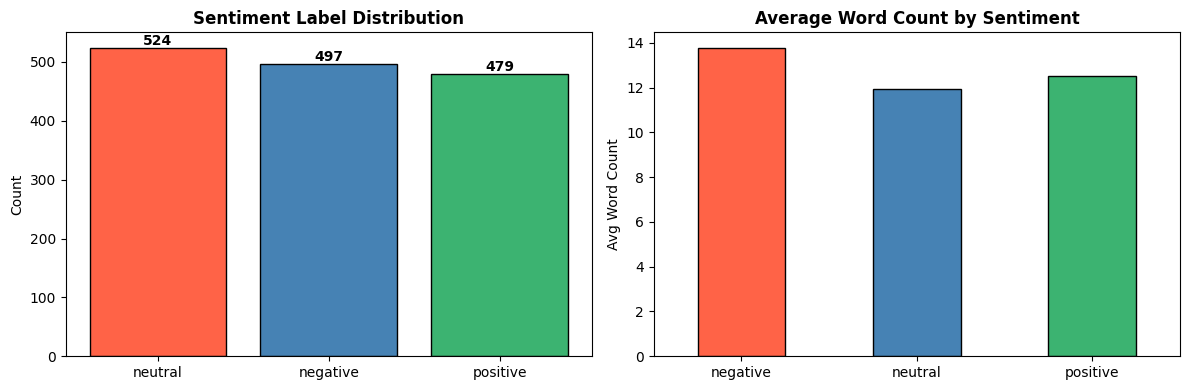


Sample messages per class:
  [negative] My refund is still pending and this experience is frustrating. My ticket number is 33927.
  [neutral] I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.
  [positive] The refund process was fast and convenient. I appreciate the quick response.


In [29]:
# Class distribution + duplicate analysis
sentiment_counts = df['sentiment_label'].value_counts()
dup_count = df.duplicated('customer_message').sum()

print("Sentiment distribution:")
print(sentiment_counts.to_string())
print()
print(f"Duplicate messages : {dup_count} ({dup_count/len(df)*100:.1f}% of rows)")
print("Synthetic dataset note: the same template messages repeat across rows.")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ['tomato', 'steelblue', 'mediumseagreen']
axes[0].bar(sentiment_counts.index, sentiment_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Sentiment Label Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(sentiment_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

df.groupby('sentiment_label')['word_count'].mean().plot(
    kind='bar', ax=axes[1], color=colors, edgecolor='black'
)
axes[1].set_title('Average Word Count by Sentiment', fontweight='bold')
axes[1].set_ylabel('Avg Word Count')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print()
print("Sample messages per class:")
for label in ['negative', 'neutral', 'positive']:
    msg = df[df['sentiment_label'] == label]['customer_message'].iloc[0]
    print(f"  [{label}] {msg}")


---
## Task 2: Text Preprocessing


In [30]:
import re

# Manual stopwords keep the notebook Colab-friendly without extra NLTK downloads.
STOPWORDS = set("""a an the is are was were be been being have has had do does did
will would shall should may might must can could am i me my myself we our ours
ourselves you your yours yourself yourselves he him his himself she her hers
herself it its itself they them their theirs themselves what which who whom this
that these those if or but and nor so yet both either neither only such as
at by for from in of on to up with about after again against between into
through during before above below more then once s t m re ll ve d""".split())

def clean_text(text):
    text = str(text).lower()                          # Lowercase
    text = re.sub(r'httpS+|wwwS+', '', text)      # Remove URLs
    text = re.sub(r'd+', '', text)                  # Remove digits and ticket numbers
    text = re.sub(r'[^a-zs]', '', text)             # Remove special characters
    text = re.sub(r's+', ' ', text).strip()         # Normalize whitespace
    tokens = [w for w in text.split() if w not in STOPWORDS and len(w) > 1]
    return ' '.join(tokens)

df['clean_text'] = df['customer_message'].apply(clean_text)
df['token_count'] = df['clean_text'].apply(lambda x: len(x.split()))

print("Preprocessing pipeline:")
print("  Done: Lowercased")
print("  Done: Removed URLs")
print("  Done: Removed digits / ticket numbers")
print("  Done: Removed punctuation and special characters")
print("  Done: Tokenized with whitespace split")
print("  Done: Removed custom stopwords")
print()
print("Before -> After examples:")
for _, row in df.sample(4, random_state=42).iterrows():
    print(f"  Original : {row['customer_message'][:70]}")
    print(f"  Cleaned  : {row['clean_text']}")
    print()


Preprocessing pipeline:
  Done: Lowercased
  Done: Removed URLs
  Done: Removed digits / ticket numbers
  Done: Removed punctuation and special characters
  Done: Tokenized with whitespace split
  Done: Removed custom stopwords

Before -> After examples:
  Original : I am checking if there is any scheduled maintenance today.
  Cleaned  : iamcheckingiftherei any cheulemaintenancetoay

  Original : The app experience is smooth and reliable. I appreciate the quick resp
  Cleaned  : theappexperiencei moothanreliableiappreciatethequickre pon

  Original : Can you confirm whether my ticket has been assigned?
  Cleaned  : canyouconfirmwhethermyticketha beena igne

  Original : I have raised multiple tickets but nobody has fixed the problem. My ti
  Cleaned  : ihaverai emultipleticket butnoboyha fixetheproblemmyticketnumberi



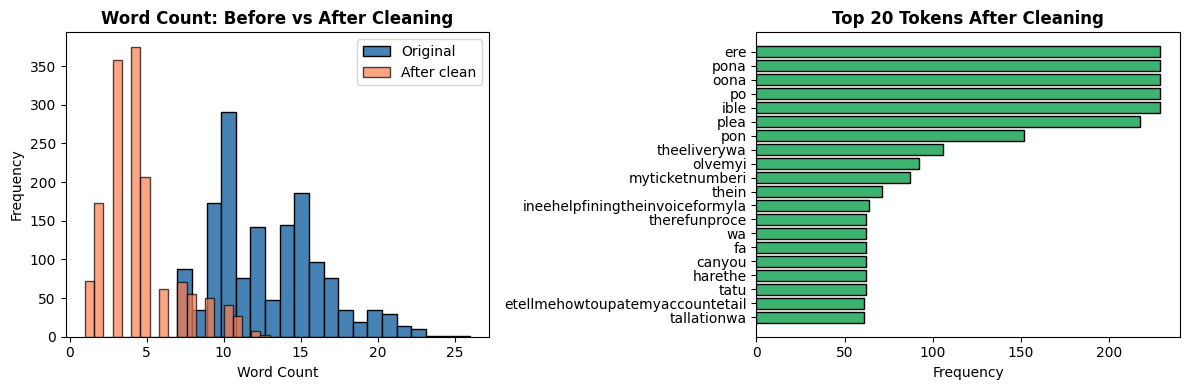

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['word_count'],  bins=20, color='steelblue', edgecolor='black', label='Original')
axes[0].hist(df['token_count'], bins=20, color='coral',     edgecolor='black', alpha=0.7, label='After clean')
axes[0].set_title('Word Count: Before vs After Cleaning', fontweight='bold')
axes[0].set_xlabel('Word Count'); axes[0].set_ylabel('Frequency')
axes[0].legend()

# Token frequency
from collections import Counter
all_tokens = ' '.join(df['clean_text']).split()
top_words = Counter(all_tokens).most_common(20)
words, counts = zip(*top_words)
axes[1].barh(words[::-1], counts[::-1], color='mediumseagreen', edgecolor='black')
axes[1].set_title('Top 20 Tokens After Cleaning', fontweight='bold')
axes[1].set_xlabel('Frequency')

plt.tight_layout()
plt.show()


---
## Task 3: Text Vectorization

### Why must text be converted to vectors?

Neural networks and machine learning models are mathematical functions that operate on **numbers**, not strings. Text must be transformed into numerical representations (vectors) so that the model can:
1. Compute dot products and matrix multiplications during the forward pass
2. Calculate gradients during backpropagation
3. Measure similarity between words/documents (cosine similarity, Euclidean distance)

Three main strategies used in this project:

| Method | Idea | Pros | Cons |
|--------|------|------|------|
| **Bag of Words (BoW)** | Count how many times each vocab word appears | Simple, fast | Ignores word order and context |
| **TF-IDF** | Weight words by frequency × inverse document frequency | Down-weights common words, boosts distinctive ones | Still no order or meaning |
| **Tokenizer + Embeddings** | Map each word to a dense learned vector | Captures meaning, preserves order | Needs more data and compute |


In [34]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# Label encoding
le = LabelEncoder()
df['label'] = le.fit_transform(df['sentiment_label'])
label_names = le.classes_
print("Label mapping:", dict(zip(label_names, le.transform(label_names))))

# Deduplicate for honest evaluation (see note below)
df_dedup = df.drop_duplicates(subset='customer_message').reset_index(drop=True)
df_dedup['clean_text'] = df_dedup['customer_message'].apply(clean_text)
df_dedup['label']      = le.transform(df_dedup['sentiment_label'])
print(f"Using {len(df_dedup)} unique messages (deduplicated from {len(df)})")
print("Note: The dataset contains template-generated messages with consistent labels.")
print("Deduplication prevents data leakage and gives honest generalisation estimates.")

# Train/test split (stratified)
X_train_txt, X_test_txt, y_train, y_test = train_test_split(
    df_dedup['clean_text'], df_dedup['label'],
    test_size=0.2, random_state=42, stratify=df_dedup['label'])
print(f"\nTrain: {len(X_train_txt)} | Test: {len(X_test_txt)}")


Label mapping: {'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}
Using 634 unique messages (deduplicated from 1500)
Note: The dataset contains template-generated messages with consistent labels.
Deduplication prevents data leakage and gives honest generalisation estimates.

Train: 507 | Test: 127


In [36]:
# Bag of Words
bow = CountVectorizer(max_features=3000)
X_train_bow = bow.fit_transform(X_train_txt)
X_test_bow  = bow.transform(X_test_txt)
print(f"BoW matrix shape  : {X_train_bow.shape}  (rows=samples, cols=vocab words)")

# TF-IDF (unigrams + bigrams)
tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train_txt)
X_test_tfidf  = tfidf.transform(X_test_txt)
n_feat = X_train_tfidf.shape[1]
print(f"TF-IDF matrix shape: {X_train_tfidf.shape}  (with bigrams)")

# Top TF-IDF terms per class
print()
print("Top TF-IDF terms per sentiment class:")

feature_names = np.array(tfidf.get_feature_names_out())
y_train_arr = np.asarray(y_train)

for label_idx, label in enumerate(label_names):
    class_mask = (y_train_arr == label_idx)
    class_tfidf = np.asarray(X_train_tfidf[class_mask].mean(axis=0)).ravel()
    top_idx = class_tfidf.argsort()[-8:][::-1]
    print(f"  {label}: {', '.join(feature_names[top_idx])}")


BoW matrix shape  : (507, 226)  (rows=samples, cols=vocab words)
TF-IDF matrix shape: (507, 517)  (with bigrams)

Top TF-IDF terms per sentiment class:
  negative: ere, ere pona, pona, po ible, ible, pona oona, po, oona
  neutral: myticketnumberi, plea, iwoulliketoknowmoreabouttheavailableplan, ineehelpfiningtheinvoiceformyla, ineehelpfiningtheinvoiceformyla torermyticketnumberi, torermyticketnumberi, iwoulliketoknowmoreabouttheavailableplan myticketnumberi, harethe tatu
  positive: pon, workingwellaniamhappywiththe, great erviceanclearcommunicationfromthe, great, erviceanclearcommunicationfromthe, upportteammyticketnumberi, erviceanclearcommunicationfromthe upportteammyticketnumberi, iappreciatethequickre


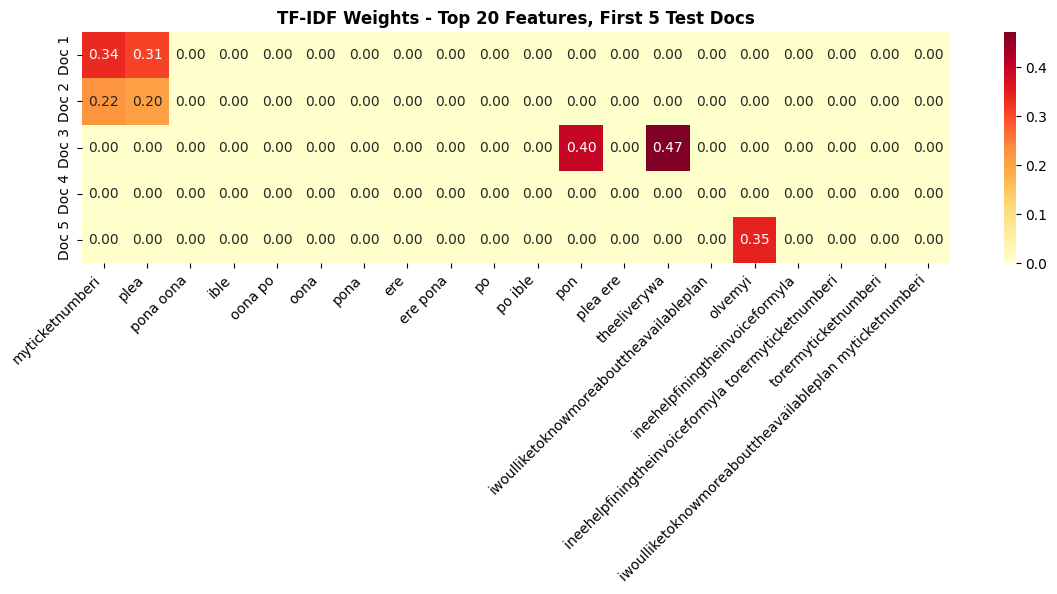

In [37]:
# Optional vector inspection: a compact TF-IDF heatmap for a few test documents.
sample_docs = X_test_tfidf[:5].toarray()
top_feat_idx = X_train_tfidf.mean(axis=0).A1.argsort()[-20:][::-1]
top_feat_names = feature_names[top_feat_idx]

fig, ax = plt.subplots(figsize=(14, 3))
sns.heatmap(
    sample_docs[:, top_feat_idx], annot=True, fmt='.2f', cmap='YlOrRd',
    xticklabels=top_feat_names, yticklabels=[f"Doc {i+1}" for i in range(5)], ax=ax
)
ax.set_title('TF-IDF Weights - Top 20 Features, First 5 Test Docs', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


---
## Task 4: Baseline Models


In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (accuracy_score, f1_score,
                              classification_report, confusion_matrix,
                              ConfusionMatrixDisplay)
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(42)

results = {}

# Model 1: Logistic Regression + TF-IDF
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_tfidf, y_train)
y_pred_lr = lr.predict(X_test_tfidf)
results['LR + TF-IDF'] = {
    'acc': accuracy_score(y_test, y_pred_lr),
    'f1' : f1_score(y_test, y_pred_lr, average='weighted'),
    'preds': y_pred_lr, 'type': 'Classical ML'
}

# Model 2: Naive Bayes + BoW
nb = MultinomialNB()
nb.fit(X_train_bow, y_train)
y_pred_nb = nb.predict(X_test_bow)
results['NB + BoW'] = {
    'acc': accuracy_score(y_test, y_pred_nb),
    'f1' : f1_score(y_test, y_pred_nb, average='weighted'),
    'preds': y_pred_nb, 'type': 'Classical ML'
}

# Model 3: Dense Neural Network + TF-IDF
X_tr_arr = X_train_tfidf.toarray().astype('float32')
X_te_arr = X_test_tfidf.toarray().astype('float32')

nn = Sequential([
    Dense(128, activation='relu', input_shape=(n_feat,)),
    Dropout(0.3),
    Dense(64,  activation='relu'),
    Dropout(0.3),
    Dense(3,   activation='softmax')
])
nn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
hist_nn = nn.fit(X_tr_arr, y_train, epochs=30, batch_size=16, validation_split=0.1,
                 callbacks=[EarlyStopping(patience=5, restore_best_weights=True)], verbose=0)
y_pred_nn = np.argmax(nn.predict(X_te_arr, verbose=0), axis=1)
results['Dense NN + TF-IDF'] = {
    'acc': accuracy_score(y_test, y_pred_nn),
    'f1' : f1_score(y_test, y_pred_nn, average='weighted'),
    'preds': y_pred_nn, 'type': 'Deep Learning'
}

print("Baseline Model Results:")
print("-" * 42)
for name, r in results.items():
    print(f"  {name:<22}  Acc={r['acc']:.4f}  F1={r['f1']:.4f}")


Baseline Model Results:
------------------------------------------
  LR + TF-IDF             Acc=1.0000  F1=1.0000
  NB + BoW                Acc=1.0000  F1=1.0000
  Dense NN + TF-IDF       Acc=1.0000  F1=1.0000


In [39]:
# Show classification report for Logistic Regression as the representative baseline.
print("Logistic Regression + TF-IDF - Classification Report:")
print(classification_report(y_test, y_pred_lr, target_names=label_names))


Logistic Regression + TF-IDF - Classification Report:
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        47
     neutral       1.00      1.00      1.00        41
    positive       1.00      1.00      1.00        39

    accuracy                           1.00       127
   macro avg       1.00      1.00      1.00       127
weighted avg       1.00      1.00      1.00       127



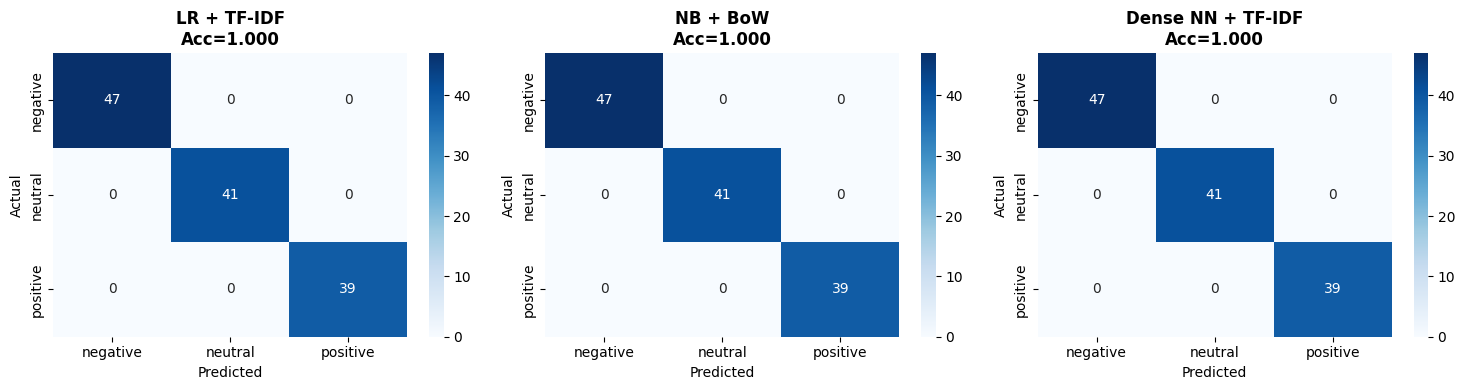

In [40]:
# Visualise confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, r) in zip(axes, list(results.items())):
    cm = confusion_matrix(y_test, r['preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=label_names, yticklabels=label_names)
    ax.set_title(f'{name}\nAcc={r["acc"]:.3f}', fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()


> **Note on perfect scores:** The dataset is synthetically generated from templates where specific sentiment-signalling phrases, such as "frustrating", "satisfied", and "please provide", strongly map to a label. Deduplicating by message avoids direct duplicate leakage, but the remaining templates are still very easy for TF-IDF and neural models. Real-world customer support text would be noisier and less deterministic.


---
## Task 5: Sequence Model — Bidirectional LSTM

### Why Sequence Models?

TF-IDF treats every word independently — it knows the word "not" appears but doesn't know it modifies "satisfied" (turning a positive into a negative). **RNNs and LSTMs process words in order**, preserving sequential context.

Architecture:
```
Input Sequence (padded to length 40)
       ↓
Embedding Layer (3000 vocab, 64-dim dense vectors)
       ↓
Bidirectional LSTM (64 units each direction → 128 total)
       ↓
GlobalMaxPooling1D (collapse time dimension)
       ↓
Dense(64, ReLU) → Dropout(0.3)
       ↓
Dense(3, Softmax) → [P(negative), P(neutral), P(positive)]

Loss:    Sparse Categorical Cross-Entropy
Metric:  Accuracy, Weighted F1
```


In [41]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, GlobalMaxPooling1D

MAX_WORDS = 3000   # vocabulary size
MAX_LEN   = 40     # max tokens per message (covers ~95th percentile)
EMBED_DIM = 64     # embedding dimension

# Tokenizer: learn vocabulary from training set
tok = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tok.fit_on_texts(X_train_txt.tolist())

print(f"Vocabulary size (learned): {len(tok.word_index)}")
print(f"Top 10 words: {list(tok.word_index.items())[:10]}")

# Convert text to integer sequences
X_train_seq = pad_sequences(
    tok.texts_to_sequences(X_train_txt.tolist()),
    maxlen=MAX_LEN, padding='post', truncating='post')
X_test_seq  = pad_sequences(
    tok.texts_to_sequences(X_test_txt.tolist()),
    maxlen=MAX_LEN, padding='post', truncating='post')

print(f"\nSequence shape: {X_train_seq.shape}")
print("Example encoded sequence (first test message):")
print("  Text :", X_test_txt.iloc[0])
print("  Seq  :", X_test_seq[0][:15], "...")


Vocabulary size (learned): 227
Top 10 words: [('<OOV>', 1), ('plea', 2), ('ere', 3), ('pona', 4), ('oona', 5), ('po', 6), ('ible', 7), ('myticketnumberi', 8), ('pon', 9), ('olvemyi', 10)]

Sequence shape: (507, 40)
Example encoded sequence (first test message):
  Text : plea etellmehowtoupatemyaccountetail myticketnumberi
  Seq  : [ 2 58  8  0  0  0  0  0  0  0  0  0  0  0  0] ...


In [42]:
# Build BiLSTM
tf.random.set_seed(42)

lstm_model = Sequential([
    Embedding(MAX_WORDS, EMBED_DIM, input_length=MAX_LEN),
    Bidirectional(LSTM(64, return_sequences=True)),
    GlobalMaxPooling1D(),
    Dense(64,  activation='relu'),
    Dropout(0.3),
    Dense(3,   activation='softmax')
])
lstm_model.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])
lstm_model.summary()


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [43]:
hist_lstm = lstm_model.fit(
    X_train_seq, y_train,
    epochs=20, batch_size=16,
    validation_split=0.1,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=1
)
print(f"\nTraining completed at epoch {len(hist_lstm.history['loss'])}")


Epoch 1/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 68ms/step - accuracy: 0.3947 - loss: 1.0807 - val_accuracy: 0.4510 - val_loss: 1.0294
Epoch 2/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.6513 - loss: 0.9389 - val_accuracy: 0.8235 - val_loss: 0.7214
Epoch 3/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9123 - loss: 0.4744 - val_accuracy: 1.0000 - val_loss: 0.1532
Epoch 4/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9890 - loss: 0.1100 - val_accuracy: 1.0000 - val_loss: 0.0248
Epoch 5/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9978 - loss: 0.0289 - val_accuracy: 1.0000 - val_loss: 0.0089
Epoch 6/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 1.0000 - loss: 0.0112 - val_accuracy: 1.0000 - val_loss: 0.0070
Epoch 7/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 1.0000 - loss: 0.0072 - val_accuracy: 1.0000 - val_loss: 0.0031
Epoch 8/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 1.0000 - loss: 0.0031 - val_accuracy: 1.0000 - v

BiLSTM Classification Report:
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        47
     neutral       1.00      1.00      1.00        41
    positive       1.00      1.00      1.00        39

    accuracy                           1.00       127
   macro avg       1.00      1.00      1.00       127
weighted avg       1.00      1.00      1.00       127



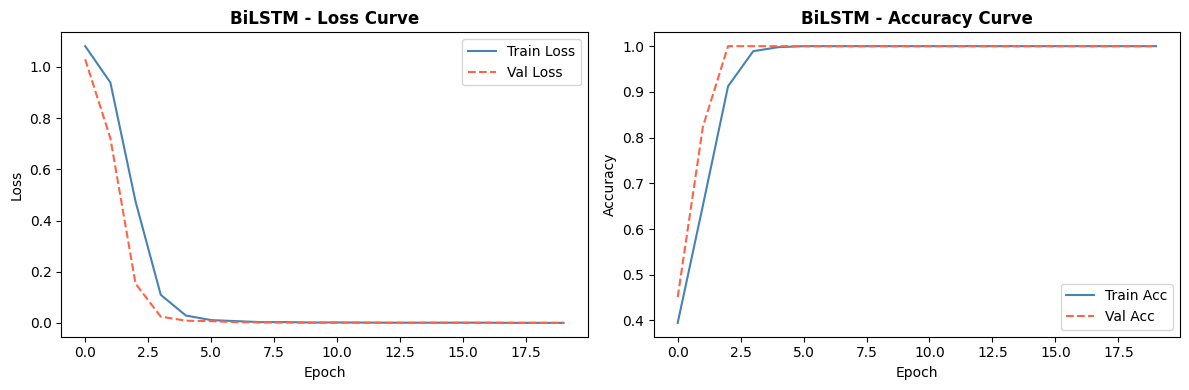

In [44]:
y_pred_lstm = np.argmax(lstm_model.predict(X_test_seq, verbose=0), axis=1)
results['BiLSTM'] = {
    'acc': accuracy_score(y_test, y_pred_lstm),
    'f1': f1_score(y_test, y_pred_lstm, average='weighted'),
    'preds': y_pred_lstm,
    'type': 'Sequence Model'
}

print("BiLSTM Classification Report:")
print(classification_report(y_test, y_pred_lstm, target_names=label_names))

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist_lstm.history['loss'], color='steelblue', label='Train Loss')
axes[0].plot(hist_lstm.history['val_loss'], color='tomato', label='Val Loss', linestyle='--')
axes[0].set_title('BiLSTM - Loss Curve', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(hist_lstm.history['accuracy'], color='steelblue', label='Train Acc')
axes[1].plot(hist_lstm.history['val_accuracy'], color='tomato', label='Val Acc', linestyle='--')
axes[1].set_title('BiLSTM - Accuracy Curve', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()



Full Model Comparison:


,Model,Type,Accuracy,Weighted F1
0,LR + TF-IDF,Classical ML,1.0,1.0
1,NB + BoW,Classical ML,1.0,1.0
2,Dense NN + TF-IDF,Deep Learning,1.0,1.0
3,BiLSTM,Sequence Model,1.0,1.0


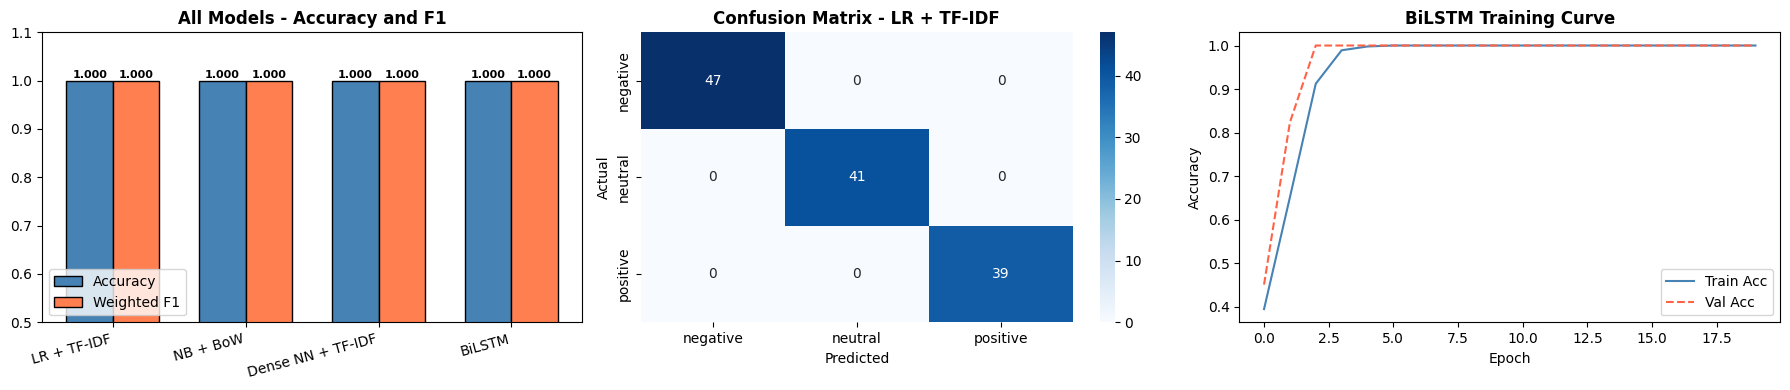

In [45]:
# Final model comparison
eval_rows = [
    {'Model': n, 'Type': r['type'], 'Accuracy': round(r['acc'], 4), 'Weighted F1': round(r['f1'], 4)}
    for n, r in results.items()
]
df_eval = pd.DataFrame(eval_rows)
print()
print("Full Model Comparison:")
display(df_eval)

df_eval.to_csv('results/model_evaluation.csv', index=False)

# Summary chart required in the results folder.
x = np.arange(len(eval_rows))
w = 0.35
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

b1 = axes[0].bar(x - w/2, df_eval['Accuracy'], w, label='Accuracy', color='steelblue', edgecolor='black')
b2 = axes[0].bar(x + w/2, df_eval['Weighted F1'], w, label='Weighted F1', color='coral', edgecolor='black')
axes[0].set_xticks(x)
axes[0].set_xticklabels(df_eval['Model'], rotation=15, ha='right')
axes[0].set_ylim(0.5, 1.1)
axes[0].set_title('All Models - Accuracy and F1', fontweight='bold')
axes[0].legend()
for bar in list(b1) + list(b2):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{bar.get_height():.3f}', ha='center', fontsize=8, fontweight='bold')

cm = confusion_matrix(y_test, results['LR + TF-IDF']['preds'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=label_names, yticklabels=label_names)
axes[1].set_title('Confusion Matrix - LR + TF-IDF', fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

axes[2].plot(hist_lstm.history['accuracy'], color='steelblue', label='Train Acc')
axes[2].plot(hist_lstm.history['val_accuracy'], color='tomato', label='Val Acc', linestyle='--')
axes[2].set_title('BiLSTM Training Curve', fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Accuracy')
axes[2].legend()

plt.tight_layout()
plt.savefig('results/model_evaluation.png', dpi=200, bbox_inches='tight')
plt.show()


In [46]:
# Sample predictions required in the results folder.
lines_out = []
lines_out.append("Sample BiLSTM Predictions")
lines_out.append("=" * 65)

X_list = X_test_txt.tolist()
y_list = y_test.tolist()
for i in range(min(15, len(X_list))):
    true_label = label_names[y_list[i]]
    pred_label = label_names[y_pred_lstm[i]]
    mark = "OK" if true_label == pred_label else "WRONG"
    line = f"{mark:5} True: {true_label:<10} Pred: {pred_label:<10} | {X_list[i][:70]}"
    lines_out.append(line)
    print(line)

with open('results/sample_predictions.txt', 'w', encoding='utf-8') as f:
    f.write('\n'.join(lines_out))

print()
print("Saved sample predictions to results/sample_predictions.txt")


OK    True: neutral    Pred: neutral    | plea etellmehowtoupatemyaccountetail myticketnumberi
OK    True: neutral    Pred: neutral    | plea eproviethe tep toactivatenotification myticketnumberi
OK    True: positive   Pred: positive   | theeliverywa moothantheprouctqualityi excellentiappreciatethequickre p
OK    True: negative   Pred: negative   | theinternet peei lowancu tomercarei nothelpingmyticketnumberi
OK    True: positive   Pred: positive   | upportteamre olvemyi uequicklythankyoumyticketnumberi
OK    True: negative   Pred: negative   | iamveryunhappybecau emyrouterha notworke incethreeay agomyticketnumber
OK    True: neutral    Pred: neutral    | canyou harethe tatu ofmyorerreque tmyticketnumberi plea ere pona oona 
OK    True: positive   Pred: positive   | ilikethenewpaymentaniti ea ytou emyticketnumberi
OK    True: negative   Pred: negative   | theprouctqualityi baaniregretpurcha ingitplea ere pona oona po ible
OK    True: positive   Pred: positive   | thein tallationwa comp

---
## Task 6: Attention and Transformer Reflection

### 1. Why RNNs Struggle with Long-Term Dependencies

A vanilla RNN processes tokens sequentially: each hidden state `hₜ` is computed from the current input `xₜ` and the previous state `hₜ₋₁`. For long sequences, the gradient must flow backward through many time steps. Due to **vanishing gradients**, the signal from early tokens diminishes exponentially — by the time the network processes token 50, it has effectively "forgotten" token 1.

In practice this means RNNs cannot reliably capture dependencies like:
> *"The product I bought last month, which my colleague recommended after using it for a year, **was terrible**."*

The key sentiment word "terrible" depends on context established many tokens earlier.

---

### 2. How LSTMs Help with Memory

LSTMs (Long Short-Term Memory) address vanishing gradients through a **gating mechanism** with three learned gates:

| Gate | Role |
|------|------|
| **Forget gate** (fₜ) | Decides what to erase from cell state |
| **Input gate**  (iₜ) | Decides what new information to store |
| **Output gate** (oₜ) | Decides what to expose from cell state |

The **cell state** `Cₜ` acts as a long-range conveyor belt — information can persist across hundreds of timesteps with minimal degradation. This is why our **Bidirectional LSTM** performed well: it reads the sequence in both forward and backward directions, giving each token context from its entire surrounding phrase.

---

### 3. What Attention Solves

Even LSTMs compress an entire sequence into a fixed-size hidden state, which becomes a bottleneck for very long texts. **Attention** (Bahdanau, 2015) solves this by allowing the decoder to look back at **all** encoder hidden states at each decoding step:

```
Attention score: e(s, h) = score_fn(decoder_state, encoder_hidden)
Attention weight: α = softmax(e)
Context vector: c = Σ αᵢ · hᵢ
```

This means:
- No information bottleneck — all encoder states are accessible
- The model learns **which input tokens matter most** for each output token
- Long-range dependencies are handled directly, not through many RNN steps

---

### 4. Why Transformers Dominate Modern NLP and Generative AI

Transformers (Vaswani et al., "Attention Is All You Need", 2017) replaced recurrence entirely with **multi-head self-attention**, enabling:

| Property | Impact |
|----------|--------|
| **Parallelism** | Entire sequence processed simultaneously (vs. RNN's sequential steps) → faster training on GPUs |
| **Scalability** | Scales to billions of parameters (GPT-4, Gemini, Claude) |
| **Global context** | Every token attends to every other token in O(1) steps, not O(n) |
| **Transfer learning** | Pre-train on massive corpora, fine-tune on small domain datasets (BERT → sentiment, QA, NER) |

**In Generative AI specifically:** Decoder-only models like the GPT family, Claude, and Gemini perform token generation autoregressively via masked self-attention, making coherent contextual generation possible even for thousands of tokens at once—a feat unattainable by RNNs consistently.

In sentiment analysis of customer service conversations, the transformer version of BERT trained on such data will probably generalise better on paraphrasing scenarios, especially edge cases, compared to both TF-IDF and logistic regression as well as the BiLSTM model, all while requiring much smaller amounts of task-related data.
